In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../SmartPhoneAddiction/data/train.csv")
test = pd.read_csv("../SmartPhoneAddiction/data/test.csv")
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [2]:
df_train = train.copy()
df_test = test.copy()

In [3]:
df_train.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [4]:
(df_train.isna().mean() * 100).round(2).sort_values(ascending=False)

social_media_hours         19.38
gaming_hours               18.34
weekend_screen_time        16.21
daily_screen_time_hours    13.86
app_opens_per_day          11.67
notifications_per_day       9.78
stress_level                7.98
work_study_hours            7.45
sleep_hours                 6.43
academic_work_impact        6.40
gender                      4.20
age                         4.18
id                          0.00
addicted_label              0.00
dtype: float64

In [5]:
num = df_train.select_dtypes(include=[np.number]).drop(columns=["id", "addicted_label"])
skew = num.skew()

pd.DataFrame({
    "skew": skew.round(2),
    "recommend": np.where(skew.abs() > 1, "median", "mean"),
}).sort_values("skew", key=abs, ascending=False)

,skew,recommend
work_study_hours,0.56,mean
gaming_hours,0.54,mean
social_media_hours,0.47,mean
notifications_per_day,-0.21,mean
daily_screen_time_hours,-0.13,mean
app_opens_per_day,-0.13,mean
weekend_screen_time,-0.06,mean
age,-0.04,mean
sleep_hours,-0.01,mean


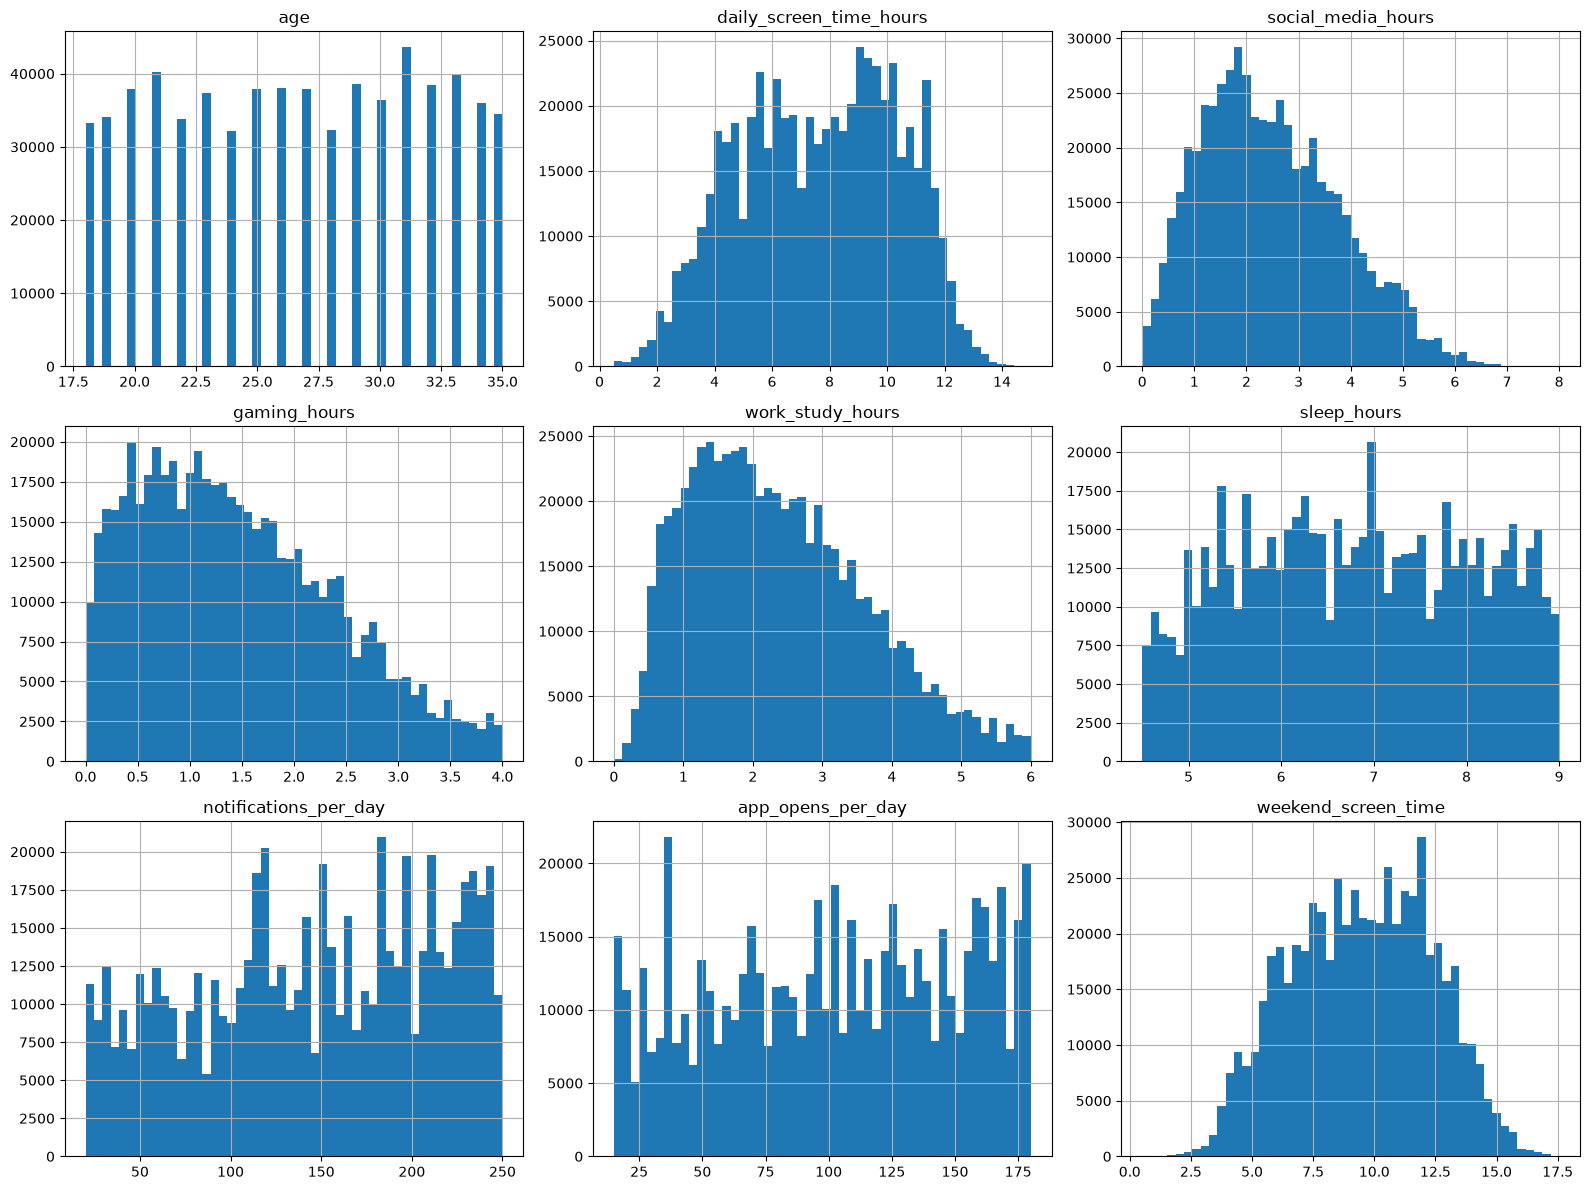

In [6]:
num = df_train.select_dtypes(include=[np.number]).drop(columns=['id','addicted_label'])
df_train[num.columns].hist(bins=50, figsize=(16, 12))
plt.tight_layout()

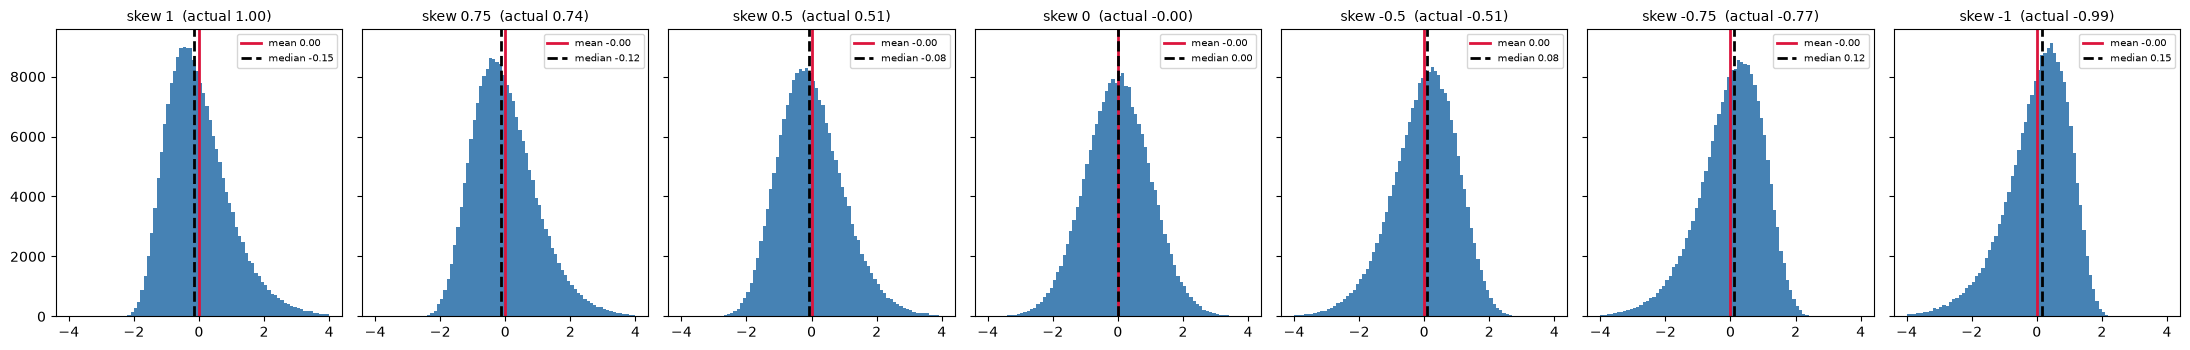

In [7]:
from scipy.optimize import brentq
from scipy.stats import skew as skewness

#Example of skewed distributions with different skewness values

def sample_skewed(g, n, rng):
    """n draws with skewness g (any real g), standardized to mean 0, sd 1."""
    if g == 0:
        x = rng.standard_normal(n)
    else:
        t = brentq(lambda t: (t + 3) * np.sqrt(t) - abs(g), 1e-12, 100)
        x = np.sign(g) * rng.lognormal(0, np.sqrt(np.log1p(t)), n)
    return (x - x.mean()) / x.std()

targets = [1, 0.75, 0.5, 0, -0.5, -0.75, -1]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(targets), figsize=(22, 3.6), sharey=True)

for ax, g in zip(axes, targets):
    x = sample_skewed(g, 200_000, rng)
    ax.hist(x, bins=80, range=(-4, 4), color="steelblue", edgecolor="none")
    ax.axvline(x.mean(), color="crimson", lw=2, label=f"mean {x.mean():.2f}")
    ax.axvline(np.median(x), color="black", lw=2, ls="--", label=f"median {np.median(x):.2f}")
    ax.set_title(f"skew {g}  (actual {skewness(x):.2f})", fontsize=10)
    ax.legend(fontsize=7)

plt.tight_layout()

In [8]:
print("train:", df_train.shape, "   test:", df_test.shape)
print("duplicate rows:", df_train.drop(columns="id").duplicated().sum())
df_train.dtypes.to_frame("dtype")

train: (691369, 14)    test: (296302, 13)
duplicate rows: 0


,dtype
id,int64
age,float64
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,float64
app_opens_per_day,float64
weekend_screen_time,float64


addicted_label
0    200895
1    490474
Name: count, dtype: int64

positive rate: 0.7094


<Axes: title={'center': 'addicted_label balance'}, xlabel='addicted_label'>

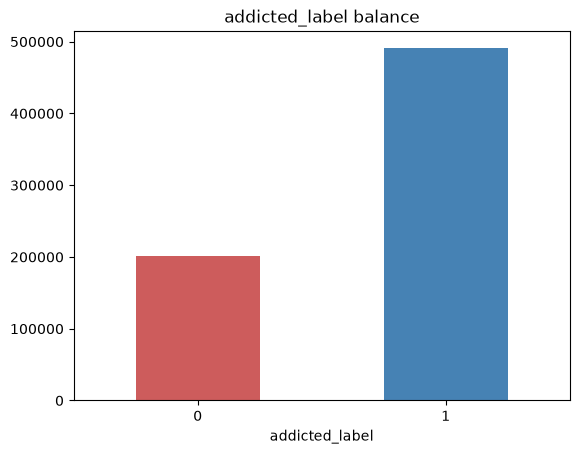

In [9]:
counts = df_train["addicted_label"].value_counts().sort_index()
print(counts)
print("\npositive rate:", round(df_train["addicted_label"].mean(), 4))

counts.plot.bar(color=["indianred", "steelblue"], rot=0, title="addicted_label balance")

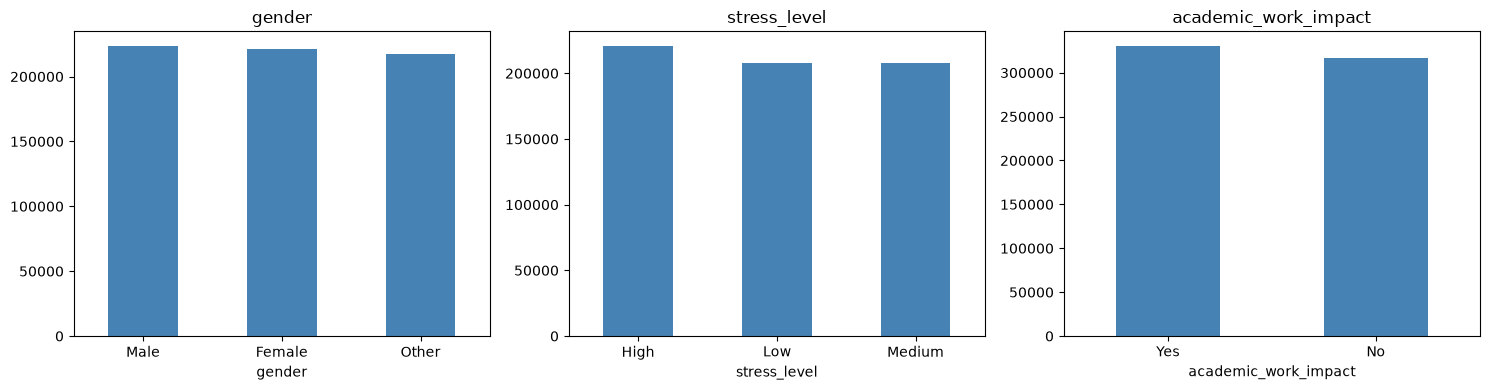

In [10]:
cat_cols = ["gender", "stress_level", "academic_work_impact"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 4))
for ax, c in zip(axes, cat_cols):
    df_train[c].value_counts().plot.bar(ax=ax, rot=0, color="steelblue", title=c)
plt.tight_layout()

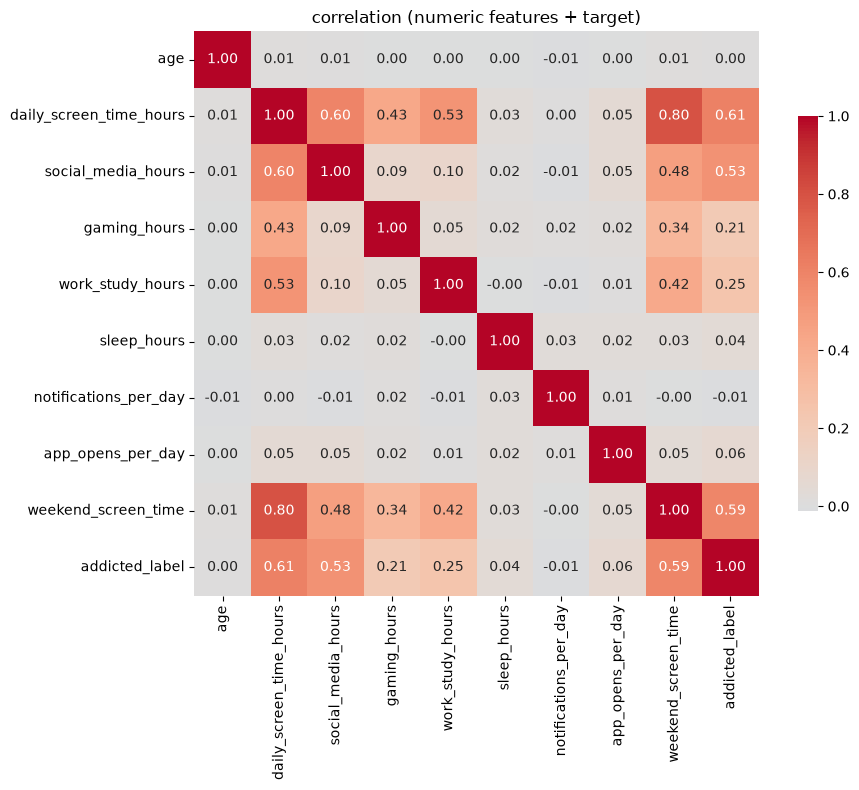

In [11]:
corr = df_train[list(num.columns) + ["addicted_label"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("correlation (numeric features + target)")
plt.tight_layout()

In [12]:
for c in cat_cols:
    rate = df_train.groupby(c, dropna=False)["addicted_label"].agg(["mean", "size"])
    print(rate.round(4), "\n")

          mean    size
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078
NaN     0.7088   29034 

                mean    size
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565
NaN           0.7090   55148 

                        mean    size
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566
NaN                   0.7095   44224 



In [13]:
features = list(num.columns)

Xdf = df_train[features].fillna(df_train[features].median())
Xdf = (Xdf - Xdf.mean()) / Xdf.std()
X = Xdf.to_numpy()

print("matrix going into PCA:", X.shape)
Xdf.describe().loc[["mean", "std", "min", "max"]].round(2)

matrix going into PCA: (691369, 9)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.71,-2.83,-2.06,-1.70,-1.94,-1.93,-2.02,-1.94,-3.44
max,1.66,2.91,4.70,3.03,3.01,1.84,1.66,1.71,3.08


In [14]:
# PCA = eigendecomposition of the covariance matrix of standardized data.
cov = np.cov(X, rowvar=False)               
eigvals, eigvecs = np.linalg.eigh(cov)      

order = eigvals.argsort()[::-1]             # largest variance first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

ratio = eigvals / eigvals.sum()
var = pd.DataFrame({
    "explained_var_ratio": ratio,
    "cumulative": ratio.cumsum(),
    "eigenvalue": eigvals,

}, index=[f"PC{i+1}" for i in range(len(eigvals))])

# biggest-loading feature in each component
var["top_feature"] = [features[np.abs(eigvecs[:, j]).argmax()] for j in range(len(eigvals))]
var.round(4)

,explained_var_ratio,cumulative,eigenvalue,top_feature
PC1,0.2747,0.2747,2.4724,daily_screen_time_hours
PC2,0.1160,0.3907,1.0439,sleep_hours
PC3,0.1114,0.5021,1.0030,age
PC4,0.1100,0.6122,0.9904,app_opens_per_day
PC5,0.1080,0.7202,0.9719,sleep_hours
PC6,0.1055,0.8257,0.9495,gaming_hours
PC7,0.0998,0.9255,0.8980,social_media_hours
PC8,0.0485,0.9740,0.4369,weekend_screen_time
PC9,0.0260,1.0000,0.2340,daily_screen_time_hours


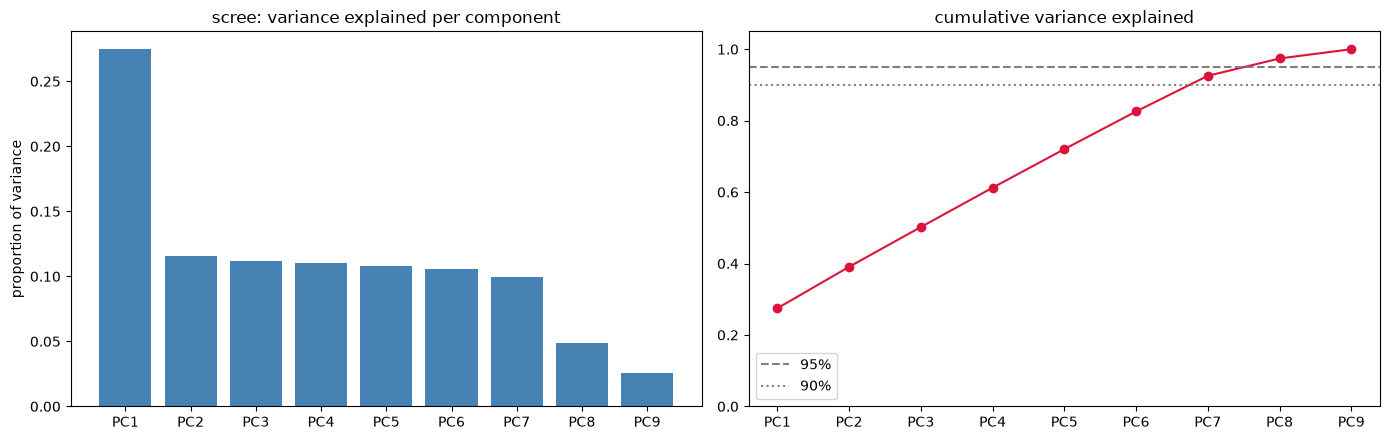

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(var.index, var["explained_var_ratio"], color="steelblue")
axes[0].set_title("scree: variance explained per component")
axes[0].set_ylabel("proportion of variance")

axes[1].plot(var.index, var["cumulative"], marker="o", color="crimson")
axes[1].axhline(0.95, ls="--", color="gray", label="95%")
axes[1].axhline(0.90, ls=":", color="gray", label="90%")
axes[1].set_title("cumulative variance explained")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()

In [16]:
CAT = ["gender", "stress_level", "academic_work_impact"]   # non-numeric columns
TARGET = "addicted_label"
N_PC = 7

# 80/20 split; test.csv has no labels and is only scored by submitting to Kaggle
n = int(len(df_train) * 0.8)

df_tr = df_train.iloc[:n]
df_va = df_train.iloc[n:]

print("train", df_tr.shape, "  val", df_va.shape, "  test (kaggle)", df_test.shape)

# a plain slice is fine as long as both halves keep the same class balance
print("positive rate   train %.4f   val %.4f" % (df_tr[TARGET].mean(), df_va[TARGET].mean()))

train (553095, 14)   val (138274, 14)   test (kaggle) (296302, 13)
positive rate   train 0.7092   val 0.7103


In [17]:
# --- preprocessing: fit on the train split, then apply to all three ---
def fit_prep(df):
    # p is a dictionary that stores everything learned from the training data,
    # so the exact same values can be applied later to the test data.
    p = {}

    # 1. values used to fill the missing data
    p["median"] = df[features].median()
    p["mode"] = df[CAT].mode().iloc[0]

    # 2. z-score:  (x - mean) / std
    z = df[features].fillna(p["median"])
    p["mean"] = z.mean()
    p["std"] = z.std()
    z = (z - p["mean"]) / p["std"]

    # 3. clip to +-3 standard deviations
    z = z.clip(-3, 3)

    # 4. PCA: eigenvectors of the covariance matrix, biggest variance first
    eigvals, eigvecs = np.linalg.eigh(np.cov(z.to_numpy(), rowvar=False))
    order = eigvals.argsort()[::-1]
    p["W"] = eigvecs[:, order][:, :N_PC]

    # 5. categories seen in training. The first one of each column is dropped:
    #    it is the default, and keeping it would repeat information.
    p["levels"] = {}
    for c in CAT:
        p["levels"][c] = sorted(df[c].dropna().unique())[1:]

    return p


def apply_prep(df, p):
    z = df[features].fillna(p["median"])
    z = (z - p["mean"]) / p["std"]
    z = z.clip(-3, 3)

    pcs = z.to_numpy() @ p["W"]          # the 7 principal components

    columns = [f"PC{i+1}" for i in range(N_PC)]

    # one column per category: 1 if the row has that category, 0 if not
    dummies = []
    for c in CAT:
        filled = df[c].fillna(p["mode"][c])
        for level in p["levels"][c]:
            dummies.append((filled == level).to_numpy(dtype=float))
            columns.append(f"{c}_{level}")

    X = np.column_stack([pcs] + dummies)
    return X, columns


# fit on df_tr only, or the validation rows leak into training
prep = fit_prep(df_tr)
X_train, columns = apply_prep(df_tr, prep)
X_val, _ = apply_prep(df_va, prep)
X_test, _ = apply_prep(df_test, prep)

y_train = df_tr[TARGET].to_numpy(dtype=float)
y_val = df_va[TARGET].to_numpy(dtype=float)

print("X_train", X_train.shape, " X_val", X_val.shape, " X_test", X_test.shape)
columns

X_train (553095, 12)  X_val (138274, 12)  X_test (296302, 12)


['PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'gender_Male',
 'gender_Other',
 'stress_level_Low',
 'stress_level_Medium',
 'academic_work_impact_Yes']

In [18]:
# --- sanity checks ---
print("NaNs left:", np.isnan(X_train).sum(), np.isnan(X_val).sum(), np.isnan(X_test).sum())

z_raw = (df_tr[features].fillna(prep["median"]) - prep["mean"]) / prep["std"]
print("cells touched by the +-3 clip: %.3f%%" % (100 * (z_raw.abs() > 3).to_numpy().mean()))
print("variance kept by PC1..PC7: %.1f%%" % (100 * var["cumulative"].iloc[N_PC - 1]))

pd.DataFrame(X_train, columns=columns).describe().loc[["mean", "std", "min", "max"]].round(2)

NaNs left: 0 0 0
cells touched by the +-3 clip: 0.067%
variance kept by PC1..PC7: 92.5%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,gender_Male,gender_Other,stress_level_Low,stress_level_Medium,academic_work_impact_Yes
mean,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.37,0.31,0.30,0.30,0.54
std,1.57,1.02,1.00,0.99,0.99,0.97,0.95,0.48,0.46,0.46,0.46,0.50
min,-5.14,-3.57,-3.15,-3.47,-3.32,-3.59,-3.93,0.00,0.00,0.00,0.00,0.00
max,5.15,3.85,2.96,3.33,3.11,3.87,4.27,1.00,1.00,1.00,1.00,1.00


In [19]:
# --- Logistic Regression from scratch ---
#
#   hypothesis:   h(x) = 1 / (1 + e^-(theta' * x))
#   cost:         J = -(1/m) * sum[ y*log(h) + (1-y)*log(1-h) ]
#   update:       theta := theta - alfa * (1/m) * sum[ (h - y) * x ]

__errors__ = []


def h(params, samples):
    """Evaluates h(x) = 1 / (1 + e^-(params' * x)) for every sample at once."""
    acum = samples @ params        # a + b*x1 + c*x2 + ... for every row
    acum = acum * (-1)
    acum = np.clip(acum, -500, 500)   # keeps e^acum from overflowing
    return 1 / (1 + np.exp(acum))

In [20]:
def cost(params, samples, y):
    """Mean error of the current params."""
    hyp = h(params, samples)
    hyp = np.clip(hyp, 1e-10, 1 - 1e-10)      # avoid the log(0) error

    error = np.where(y == 1, -np.log(hyp), -np.log(1 - hyp))
    return error.sum() / len(samples)


def show_errors(params, samples, y):
    """Same number, but also stored in __errors__ so it can be plotted later."""
    global __errors__

    mean_error_param = cost(params, samples, y)
    __errors__.append(mean_error_param)
    return mean_error_param


def GD(params, samples, y, alfa):
    """One run of gradient descent over the whole sample set."""
    error = h(params, samples) - y
    acum = samples.T @ error                  # sumatory part of the formula
    return params - alfa * (1 / len(samples)) * acum

In [21]:
# x0 = 1 on every row, so params[0] is the intercept
samples = np.hstack([np.ones((len(X_train), 1)), X_train])
samples_val = np.hstack([np.ones((len(X_val), 1)), X_val])
y = y_train.astype(float)

params = np.zeros(samples.shape[1])
params[0] = np.log(y.mean() / (1 - y.mean()))   # start at the base-rate log-odds

alfa = 0.5        # learning rate

print("samples", samples.shape, "  val", samples_val.shape, "  params", params.shape)
print("error before training:", round(cost(params, samples, y), 5))

samples (553095, 13)   val (138274, 13)   params (13,)
error before training: 0.60286


In [22]:
# start at epoch 0: every weight is still zero, so this point is the baseline
__errors__ = [cost(params, samples, y)]
val_errors = [cost(params, samples_val, y_val)]
epoch = 0

while True:   # run gradient descent until it stops improving
    oldparams = params.copy()
    params = GD(params, samples, y, alfa)
    error = show_errors(params, samples, y)
    val_errors.append(cost(params, samples_val, y_val))
    epoch = epoch + 1

    if epoch % 100 == 0:
        print(f"epoch {epoch:4d}   error {error:.5f}")

    # local minimum: params stopped moving, or error is basically zero
    if np.allclose(oldparams, params, atol=1e-6) or error < 0.0001 or epoch >= 2000:
        break

print(f"\nstopped at epoch {epoch}, final error {error:.5f}")
print("train %.5f   val %.5f   gap %+.5f"
      % (__errors__[-1], val_errors[-1], val_errors[-1] - __errors__[-1]))

epoch  100   error 0.34751


epoch  200   error 0.34692


epoch  300   error 0.34679


epoch  400   error 0.34673


epoch  500   error 0.34671


...

epoch 1300   error 0.34669


epoch 1400   error 0.34669


epoch 1500   error 0.34669


epoch 1600   error 0.34669



stopped at epoch 1663, final error 0.34669
train 0.34669   val 0.34615   gap -0.00054


baseline (no features) 0.60286
model                  0.34615   ->  43% lower


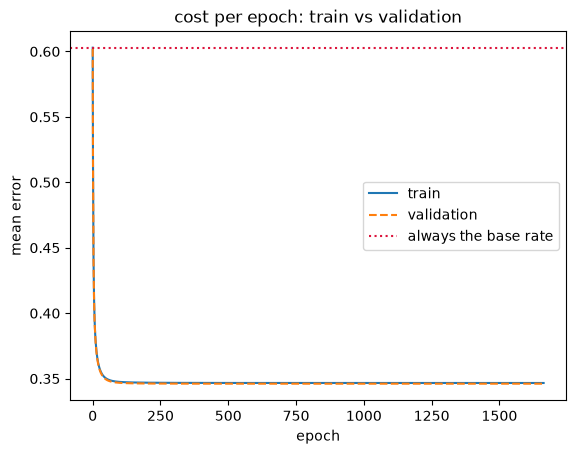

In [23]:
# red line = uses no feature at all, always predicts the base rate
base = y.mean()
baseline = -(base * np.log(base) + (1 - base) * np.log(1 - base))

plt.plot(__errors__, label="train")
plt.plot(val_errors, "--", label="validation")
plt.axhline(baseline, color="crimson", ls=":", label="always the base rate")
plt.xlabel("epoch")
plt.ylabel("mean error")
plt.title("cost per epoch: train vs validation")
plt.legend()

print("baseline (no features) %.5f" % baseline)
print("model                  %.5f   ->  %.0f%% lower" % (val_errors[-1], 100 * (1 - val_errors[-1] / baseline)))

In [24]:
pd.Series(params, index=["intercept"] + columns).round(4).to_frame("params")

,params
intercept,1.7029
PC1,-1.4640
PC2,-0.0494
PC3,0.1513
PC4,0.2100
PC5,-0.0527
PC6,-0.0623
PC7,-0.9792
gender_Male,0.0504
gender_Other,-0.0283


In [25]:
# --- gradient check: is the GD formula right? ---
# Nudge one param up and down, see how the error changes, compare to the formula.

def cost(params_try):
    hyp = np.clip(h(params_try, samples), 1e-10, 1 - 1e-10)
    return np.where(y == 1, -np.log(hyp), -np.log(1 - hyp)).sum() / len(samples)

j = 1                      # params[1] = PC1
eps = 1e-5

params_up = params.copy()
params_up[j] = params_up[j] + eps

params_down = params.copy()
params_down[j] = params_down[j] - eps

numeric_gradient = (cost(params_up) - cost(params_down)) / (2 * eps)
our_gradient = (samples.T @ (h(params, samples) - y) / len(samples))[j]

print("numeric gradient:", numeric_gradient)
print("our gradient    :", our_gradient)

numeric gradient: 2.3505364321607655e-07
our gradient    : 2.350501811494044e-07


In [26]:
# --- AUC by hand (the competition metric) ---
# AUC = the chance a random positive scores higher than a random negative.

def roc_auc(y_true, scores):
    order = scores.argsort()
    ranks = np.empty(len(scores))
    ranks[order] = np.arange(1, len(scores) + 1)   # rank 1 = lowest score

    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


train_pred = h(params, samples)
val_pred = h(params, np.hstack([np.ones((len(X_val), 1)), X_val]))
print("train AUC:", round(roc_auc(y, train_pred), 5))
print("val   AUC:", round(roc_auc(y_val, val_pred), 5))

shuffled = np.random.default_rng(0).permutation(train_pred)
print("shuffled AUC (should be ~0.5):", round(roc_auc(y, shuffled), 5))

train AUC: 0.91096


val   AUC: 0.91106


shuffled AUC (should be ~0.5): 0.5007


In [27]:
# --- predict the test set and write the submission ---
test_samples = np.hstack([np.ones((len(X_test), 1)), X_test])
test_pred = h(params, test_samples)

submission = pd.DataFrame({"id": df_test["id"], "addicted_label": test_pred})
submission.to_csv("../outputs/submission_scratch.csv", index=False)

print(submission.shape)
submission.head()

(296302, 2)


,id,addicted_label
0,691369,0.888537
1,691370,0.844361
2,691371,0.972242
3,691372,0.921022
4,691373,0.986599
